<a href="https://colab.research.google.com/github/oihika/Spatial-Temporal-Storage-Optimization-for-Renewable-Power-Integration/blob/main/python%20code%20with%20output.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DASPI environment ready.

Coordinate validation successful.
Latitude  : 23.181500
Longitude : 79.986400
Location  : Jabalpur, Madhya Pradesh, India

Downloaded 8,760 hourly observations.

LOCATION RESOURCE DIAGNOSTIC
Mean solar resource indicator : 199.330
Mean wind speed               : 3.050 m/s
Maximum wind speed            : 10.840 m/s
Mean temperature              : 24.58 °C

SYSTEM CALIBRATION
Solar capacity       : 938.45 MW
Wind capacity        : 5000.00 MW
Hydro capacity       : 100.00 MW
Annual load          : 4,380,000 MWh

DEFICIT SIGNATURE
Number of deficit events : 355
Longest deficit         : 48.0 h
Mean deficit duration   : 17.9 h
Maximum deficit power   : 602.57 MW
Total deficit energy    : 2,379,990 MWh

Duration Mismatch Index (DMI): 1.3833

Building DASPI MILP with 39,430 variables...
Running mixed-integer/linear optimisation...

DASPI optimisation completed.
Optimization terminated successfully. (HiGHS Status 7: Optimal)

DASPI OPTIMAL STORAGE PORTFOLIO
     Techn

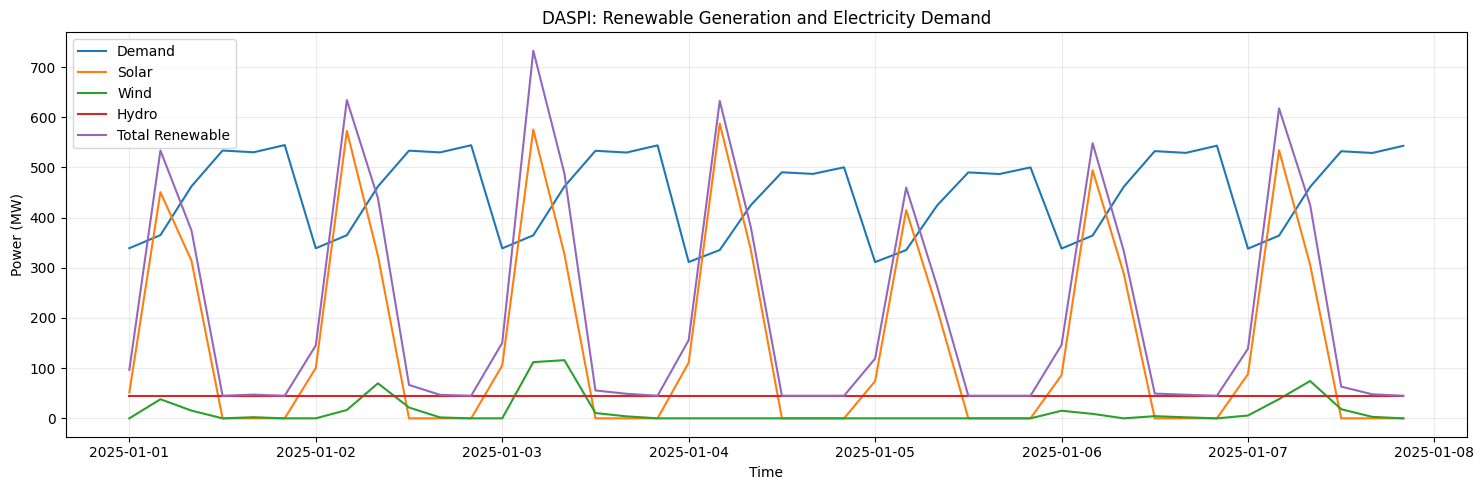

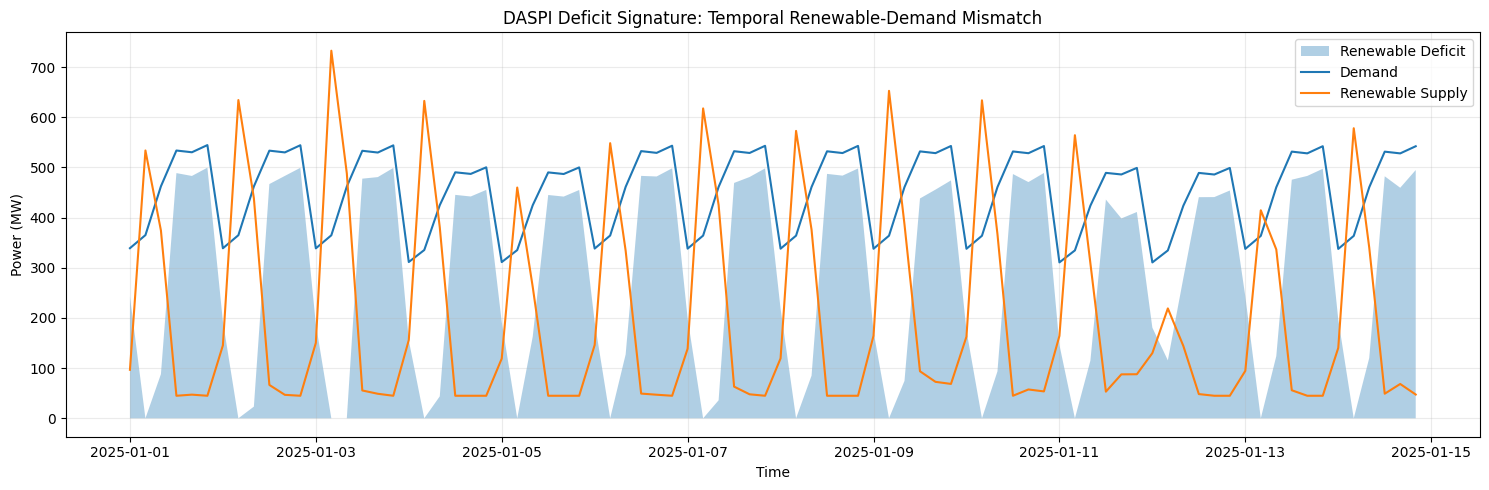

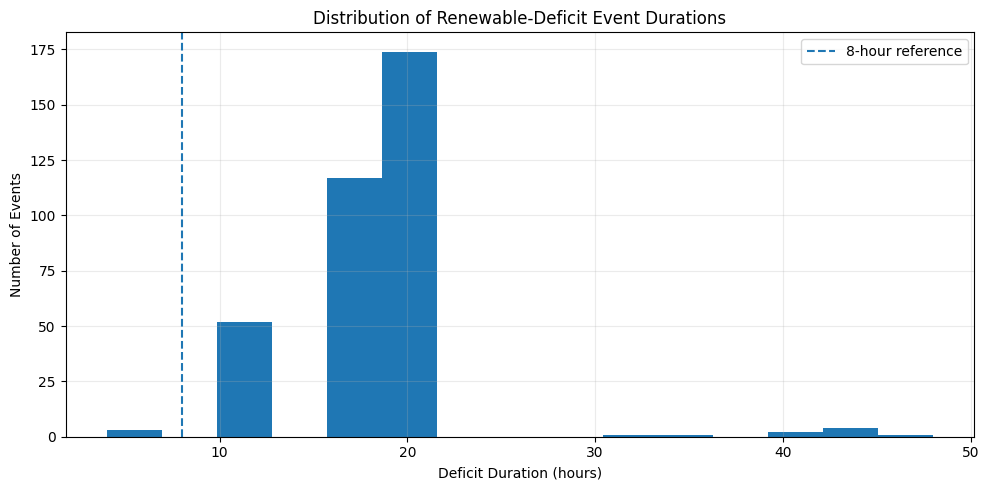

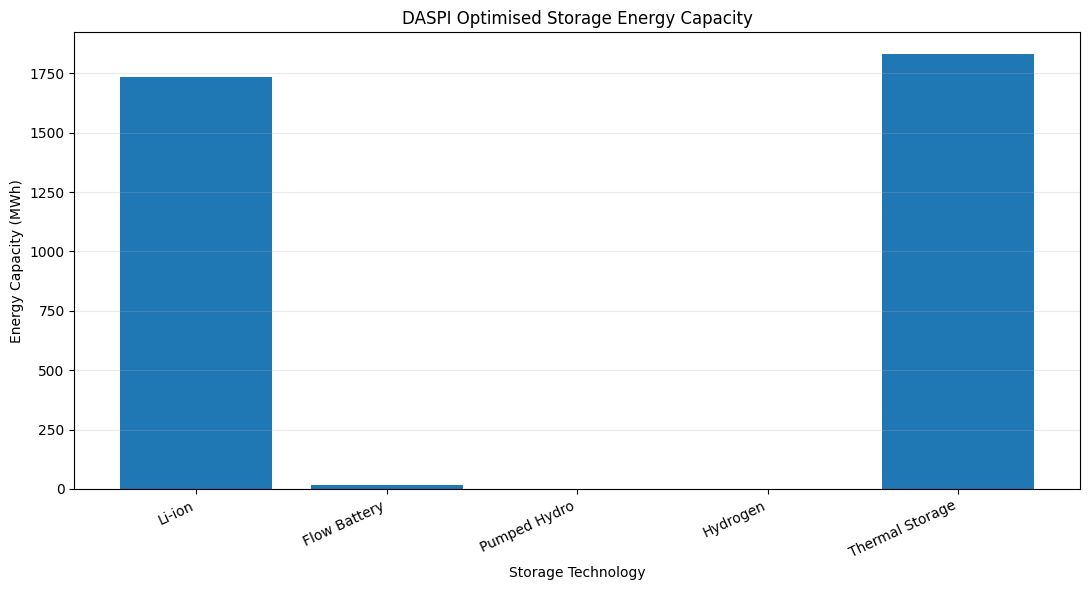

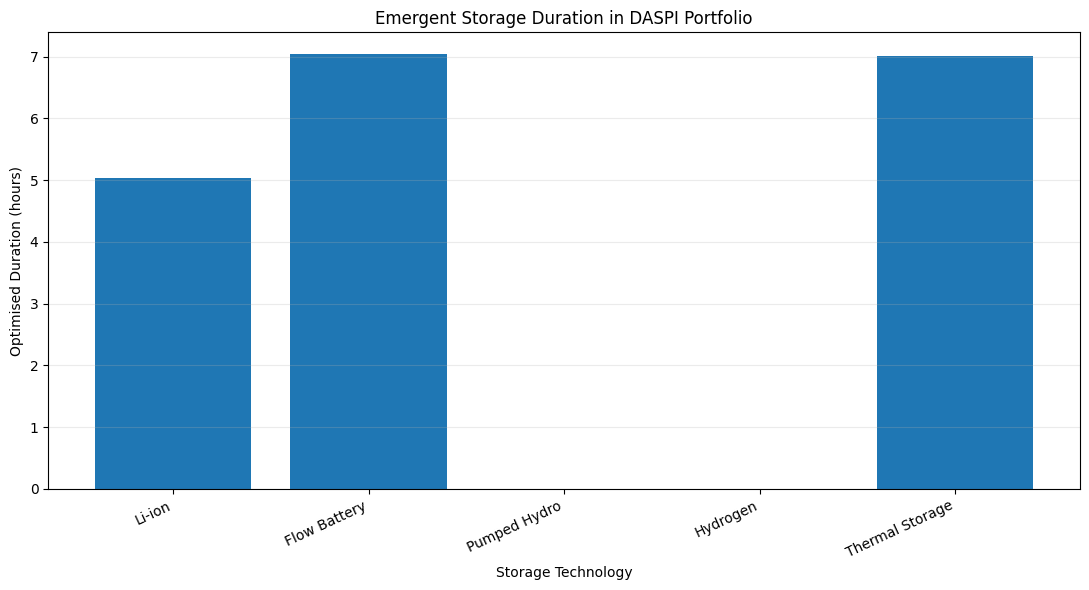

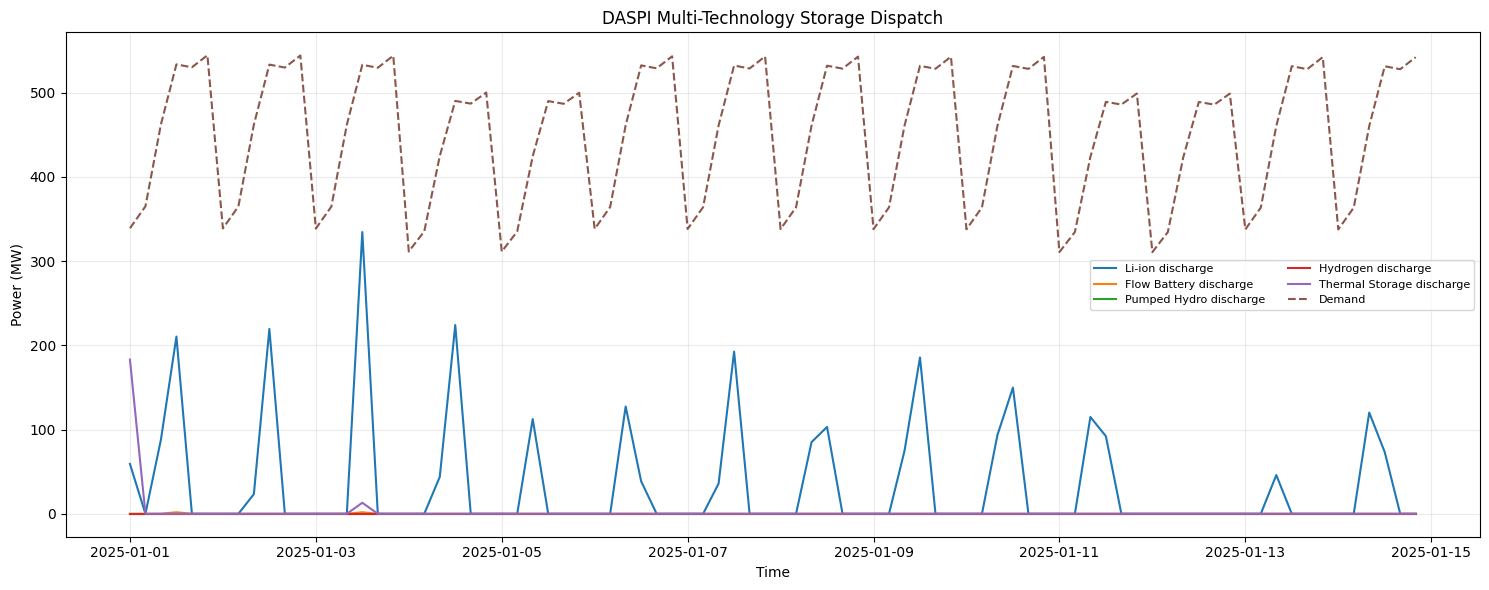

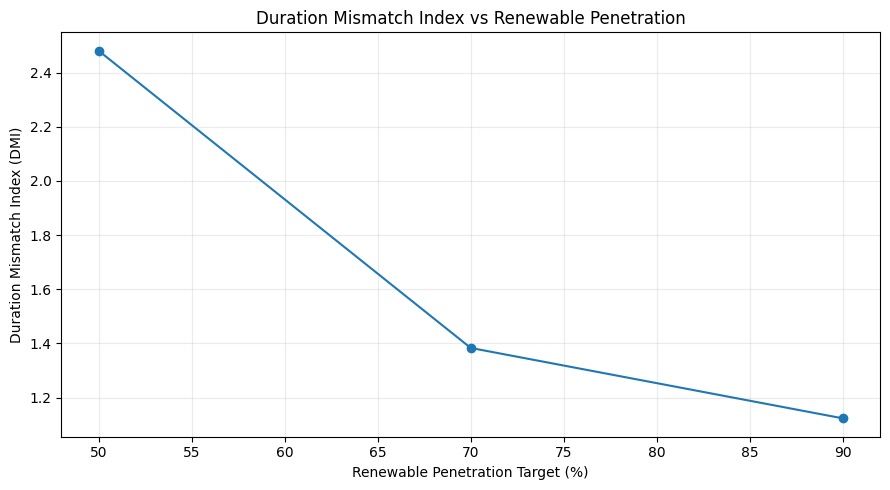

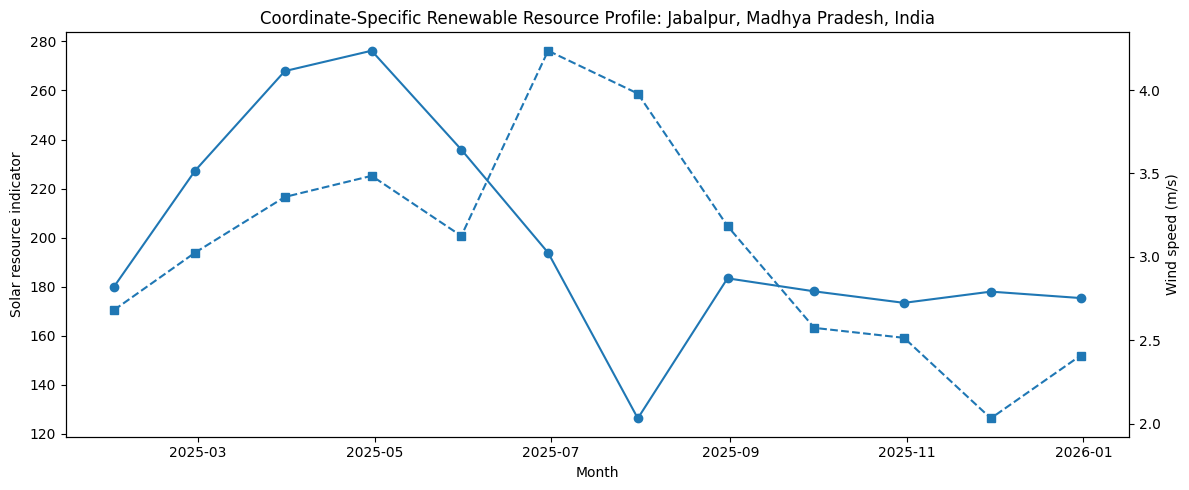



DASPI RESEARCH RUN COMPLETED
Location                           : Jabalpur, Madhya Pradesh, India
Latitude                           : 23.1815
Longitude                          : 79.9864
Renewable_Target                   : 0.7000
Solar_Capacity_MW                  : 938.4535
Wind_Capacity_MW                   : 5000.0000
Hydro_Capacity_MW                  : 100.0000
DMI                                : 1.3833
RASV                               : 0.0000
TSCR                               : 0.0015
Reliability                        : 1.0000
Renewable_Utilisation              : 0.9225
Curtailment_MWh                    : 223929.6479
Grid_Import_MWh                    : 1830510.1090
Unserved_Energy_MWh                : 0.0000
Total_Storage_Power_MW             : 608.5163
Total_Storage_Energy_MWh           : 3581.1975

Generated files:
  ✓ DASPI_system_timeseries.csv
  ✓ DASPI_deficit_events.csv
  ✓ DASPI_optimal_storage_portfolio.csv
  ✓ DASPI_scenario_comparison.csv
  ✓ DASPI_sensitiv

In [1]:
# ================================================================
# DASPI: Duration-Adaptive Storage Portfolio Intelligence
# ================================================================
# Research prototype for:
# "Duration-Adaptive Storage Portfolio Intelligence (DASPI)
#  for High-Renewable-Penetration Power Systems"
#
# Author: Oihika Arpit
#
# IMPORTANT:
# This is a reproducible RESEARCH PROTOTYPE.
# Do not present generated results as final empirical findings
# until the assumptions, datasets and technology parameters
# are replaced/validated with cited sources.
#
# Main architecture:
#
# Coordinates
#     ↓
# NASA POWER renewable resource data
#     ↓
# Solar + Wind + Hydro + Demand
#     ↓
# Renewable-deficit signature
#     ↓
# Duration/severity analysis
#     ↓
# DMI
#     ↓
# Multi-technology optimisation
#     ↓
# Li-ion / Flow / PHS / H2 / Thermal
#     ↓
# DMI + RASV + TSCR
#     ↓
# Comparative + sensitivity analysis
#     ↓
# Publication figures + CSV results
# ================================================================


# ================================================================
# 0. INSTALL / IMPORT
# ================================================================

import sys
import subprocess
import importlib

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "requests": "requests"
}

for package, pip_name in required_packages.items():
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pip_name]
        )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import math
import os
import warnings

from scipy.optimize import milp, LinearConstraint, Bounds

warnings.filterwarnings("ignore")

print("DASPI environment ready.")


# ================================================================
# 1. USER CONFIGURATION
# ================================================================
#
# CHANGE THESE VALUES FOR YOUR CASE STUDY.
#
# Example:
# Jabalpur:     23.1815, 79.9864
# Bhopal:       23.2599, 77.4126
# Indore:       22.7196, 75.8577
#
# You can enter ANY location within valid geographic bounds.

LATITUDE = 23.1815
LONGITUDE = 79.9864

LOCATION_NAME = "Jabalpur, Madhya Pradesh, India"

# Coordinate constraint:
# Set this to True if you want the optimisation study restricted
# to a predefined geographical study region.

USE_COORDINATE_CONSTRAINT = True

# Example Central India boundary
LAT_MIN = 20.0
LAT_MAX = 25.5
LON_MIN = 74.0
LON_MAX = 82.5


# ================================================================
# TIME / DATA CONFIGURATION
# ================================================================

START_DATE = "2025-01-01"
END_DATE   = "2025-12-31"

# 4-hour resolution is recommended for Colab prototype optimisation.
#
# For final research:
# RESAMPLE_HOURS = 1
#
# will provide hourly modelling but will require substantially
# more computational resources.

RESAMPLE_HOURS = 4

TIME_STEP = RESAMPLE_HOURS


# ================================================================
# RENEWABLE CONFIGURATION
# ================================================================

TARGET_RENEWABLE_SHARE = 0.70

# Solar / wind share of renewable capacity proxy
SOLAR_SHARE = 0.60
WIND_SHARE = 0.40

# Hydro is treated as an additional dispatchable renewable source.
HYDRO_CAPACITY_MW = 100.0

# Maximum renewable installed capacity allowed
MAX_SOLAR_MW = 5000.0
MAX_WIND_MW = 5000.0


# ================================================================
# DEFICIT DETECTION PARAMETERS
# ================================================================

# Deficit threshold:
# Positive residual demand means renewable generation
# is insufficient to meet demand.

DEFICIT_THRESHOLD_MW = 0.0

# Minimum duration of an event
MIN_DEFICIT_DURATION_HOURS = 4


# ================================================================
# STORAGE TECHNOLOGIES
# ================================================================
#
# Values below are MODEL ASSUMPTIONS for the prototype.
# Replace them with properly sourced values before publication.
#
# power_capex: $/kW
# energy_capex: $/kWh
# eta_ch: charging efficiency
# eta_dis: discharging efficiency
# self_discharge: hourly fractional loss
# min_duration / max_duration: technology operating range
#
# Duration is NOT imposed as the final answer.
# The optimisation chooses E/P inside the technology's
# feasible operating envelope.

STORAGE = {

    "Li-ion": {
        "power_capex": 300,
        "energy_capex": 180,
        "eta_ch": 0.95,
        "eta_dis": 0.95,
        "self_discharge": 0.0001,
        "min_duration": 1,
        "max_duration": 8,
        "variable_cost": 0.002
    },

    "Flow Battery": {
        "power_capex": 500,
        "energy_capex": 100,
        "eta_ch": 0.88,
        "eta_dis": 0.88,
        "self_discharge": 0.00005,
        "min_duration": 4,
        "max_duration": 24,
        "variable_cost": 0.003
    },

    "Pumped Hydro": {
        "power_capex": 1200,
        "energy_capex": 40,
        "eta_ch": 0.85,
        "eta_dis": 0.90,
        "self_discharge": 0.00001,
        "min_duration": 6,
        "max_duration": 100,
        "variable_cost": 0.001
    },

    "Hydrogen": {
        "power_capex": 900,
        "energy_capex": 15,
        "eta_ch": 0.65,
        "eta_dis": 0.55,
        "self_discharge": 0.000001,
        "min_duration": 12,
        "max_duration": 1000,
        "variable_cost": 0.010
    },

    "Thermal Storage": {
        "power_capex": 400,
        "energy_capex": 50,
        "eta_ch": 0.80,
        "eta_dis": 0.80,
        "self_discharge": 0.001,
        "min_duration": 4,
        "max_duration": 72,
        "variable_cost": 0.004
    }
}

TECHNOLOGIES = list(STORAGE.keys())
N_TECH = len(TECHNOLOGIES)


# ================================================================
# 2. COORDINATE VALIDATION
# ================================================================

def validate_coordinates(lat, lon):

    if not (-90 <= lat <= 90):
        raise ValueError("Latitude must be between -90 and +90 degrees.")

    if not (-180 <= lon <= 180):
        raise ValueError("Longitude must be between -180 and +180 degrees.")

    if USE_COORDINATE_CONSTRAINT:

        inside = (
            LAT_MIN <= lat <= LAT_MAX
            and
            LON_MIN <= lon <= LON_MAX
        )

        if not inside:
            raise ValueError(
                f"""
COORDINATE CONSTRAINT VIOLATION

Selected coordinate:
Latitude  = {lat}
Longitude = {lon}

Allowed study region:
Latitude  = {LAT_MIN} to {LAT_MAX}
Longitude = {LON_MIN} to {LON_MAX}

Change the coordinates or disable USE_COORDINATE_CONSTRAINT.
"""
            )

    print("\nCoordinate validation successful.")
    print(f"Latitude  : {lat:.6f}")
    print(f"Longitude : {lon:.6f}")
    print(f"Location  : {LOCATION_NAME}")

    return True


validate_coordinates(LATITUDE, LONGITUDE)


# ================================================================
# 3. NASA POWER DATA DOWNLOAD
# ================================================================

def get_nasa_power_data(lat, lon, start_date, end_date):

    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"

    params = {
        "parameters": "ALLSKY_SFC_SW_DWN,WS10M,T2M",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start_date.replace("-", ""),
        "end": end_date.replace("-", ""),
        "format": "JSON",
        "time-standard": "UTC"
    }

    print("\nDownloading NASA POWER renewable-resource data...")

    response = requests.get(url, params=params, timeout=60)

    response.raise_for_status()

    data = response.json()

    properties = data["properties"]["parameter"]

    solar = properties["ALLSKY_SFC_SW_DWN"]
    wind = properties["WS10M"]
    temp = properties["T2M"]

    rows = []

    for timestamp in solar.keys():

        rows.append({
            "datetime": pd.to_datetime(timestamp, format="%Y%m%d%H"),
            "solar_resource": solar[timestamp],
            "wind_speed": wind[timestamp],
            "temperature": temp[timestamp]
        })

    df = pd.DataFrame(rows)

    df = df.sort_values("datetime")
    df = df.set_index("datetime")

    # Replace NASA missing-value convention if encountered
    df = df.replace(-999, np.nan)

    df = df.interpolate()
    df = df.dropna()

    print(f"Downloaded {len(df):,} hourly observations.")

    return df


resource = get_nasa_power_data(
    LATITUDE,
    LONGITUDE,
    START_DATE,
    END_DATE
)


# ================================================================
# 4. RENEWABLE RESOURCE CHECK
# ================================================================

print("\n================================================")
print("LOCATION RESOURCE DIAGNOSTIC")
print("================================================")

print(
    f"Mean solar resource indicator : "
    f"{resource['solar_resource'].mean():.3f}"
)

print(
    f"Mean wind speed               : "
    f"{resource['wind_speed'].mean():.3f} m/s"
)

print(
    f"Maximum wind speed            : "
    f"{resource['wind_speed'].max():.3f} m/s"
)

print(
    f"Mean temperature              : "
    f"{resource['temperature'].mean():.2f} °C"
)


# ================================================================
# 5. WIND POWER CURVE
# ================================================================

def wind_power_curve(v):

    """
    Simplified normalized wind-turbine power curve.

    Cut-in  = 3 m/s
    Rated   = 12 m/s
    Cut-out = 25 m/s
    """

    v = np.asarray(v)

    power = np.zeros_like(v, dtype=float)

    mask1 = (v >= 3) & (v < 12)

    power[mask1] = (
        (v[mask1]**3 - 3**3)
        /
        (12**3 - 3**3)
    )

    mask2 = (v >= 12) & (v <= 25)

    power[mask2] = 1.0

    return np.clip(power, 0, 1)


resource["wind_cf"] = wind_power_curve(
    resource["wind_speed"].values
)


# ================================================================
# 6. SOLAR NORMALISATION
# ================================================================

# NASA POWER ALLSKY_SFC_SW_DWN is used as the solar resource signal.
# The profile is normalised for system-level modelling.

solar = resource["solar_resource"].clip(lower=0)

if solar.max() > 0:
    resource["solar_cf"] = solar / solar.max()
else:
    raise ValueError("Solar resource data contains no usable values.")


# ================================================================
# 7. RESAMPLE DATA
# ================================================================

df = resource.resample(
    f"{RESAMPLE_HOURS}h"
).mean()

df = df.dropna()


# ================================================================
# 8. REPRESENTATIVE ELECTRICITY DEMAND
# ================================================================
#
# IMPORTANT:
# This is a transparent modelling profile, NOT measured electricity
# demand. Replace it with actual Central India demand data for
# publication.
#
# The profile contains:
# - daily cycle
# - evening peak
# - seasonal variation
# - weekday/weekend effect

def create_demand_profile(index):

    hour = index.hour.values
    dayofyear = index.dayofyear.values
    weekday = index.dayofweek.values

    daily_component = (
        0.65
        + 0.15 * np.sin(
            2 * np.pi * (hour - 7) / 24
        )
        + 0.20 * np.exp(
            -((hour - 20) / 3.0)**2
        )
    )

    seasonal_component = (
        1.0
        + 0.10 * np.cos(
            2 * np.pi * (dayofyear - 200) / 365
        )
    )

    weekend_component = np.where(
        weekday >= 5,
        0.92,
        1.0
    )

    demand = (
        daily_component
        * seasonal_component
        * weekend_component
    )

    # Normalise around 500 MW mean demand
    demand = (
        demand
        /
        demand.mean()
        *
        500.0
    )

    return demand


df["demand_MW"] = create_demand_profile(df.index)


# ================================================================
# 9. HYDRO PROFILE
# ================================================================
#
# Placeholder hydro availability profile.
#
# Replace this with actual reservoir / river-flow / hydro dispatch
# data in the final study.

month = df.index.month.values

hydro_monthly_cf = {
    1: 0.45,
    2: 0.42,
    3: 0.40,
    4: 0.38,
    5: 0.40,
    6: 0.55,
    7: 0.80,
    8: 0.85,
    9: 0.78,
    10: 0.65,
    11: 0.55,
    12: 0.48
}

df["hydro_cf"] = [
    hydro_monthly_cf[m]
    for m in month
]

df["hydro_MW"] = (
    HYDRO_CAPACITY_MW
    * df["hydro_cf"]
)


# ================================================================
# 10. INITIAL RENEWABLE CAPACITY CALIBRATION
# ================================================================
#
# We calculate renewable capacities to approximately reach the
# target renewable-energy contribution.
#
# Solar and wind are calibrated using the observed resource profiles.

annual_load_MWh = (
    df["demand_MW"].sum()
    * RESAMPLE_HOURS
)

annual_hydro_MWh = (
    df["hydro_MW"].sum()
    * RESAMPLE_HOURS
)

target_RE_MWh = (
    TARGET_RENEWABLE_SHARE
    * annual_load_MWh
)

remaining_RE_MWh = max(
    target_RE_MWh - annual_hydro_MWh,
    0
)

solar_cf_mean = df["solar_cf"].mean()
wind_cf_mean = df["wind_cf"].mean()

# Allocate the remaining renewable energy between solar and wind.
solar_energy_target = remaining_RE_MWh * SOLAR_SHARE
wind_energy_target = remaining_RE_MWh * WIND_SHARE

solar_capacity = (
    solar_energy_target
    /
    (
        solar_cf_mean
        * 8760
    )
)

wind_capacity = (
    wind_energy_target
    /
    (
        wind_cf_mean
        * 8760
    )
)

solar_capacity = min(
    solar_capacity,
    MAX_SOLAR_MW
)

wind_capacity = min(
    wind_capacity,
    MAX_WIND_MW
)

df["solar_MW"] = (
    df["solar_cf"]
    * solar_capacity
)

df["wind_MW"] = (
    df["wind_cf"]
    * wind_capacity
)

df["renewable_available_MW"] = (
    df["solar_MW"]
    +
    df["wind_MW"]
    +
    df["hydro_MW"]
)

df["net_load_MW"] = (
    df["demand_MW"]
    -
    df["renewable_available_MW"]
)

print("\n================================================")
print("SYSTEM CALIBRATION")
print("================================================")

print(
    f"Solar capacity       : {solar_capacity:.2f} MW"
)

print(
    f"Wind capacity        : {wind_capacity:.2f} MW"
)

print(
    f"Hydro capacity       : {HYDRO_CAPACITY_MW:.2f} MW"
)

print(
    f"Annual load          : {annual_load_MWh:,.0f} MWh"
)


# ================================================================
# 11. RENEWABLE DEFICIT SIGNATURE
# ================================================================

df["deficit_MW"] = np.maximum(
    df["demand_MW"]
    -
    df["renewable_available_MW"],
    0
)

df["surplus_MW"] = np.maximum(
    df["renewable_available_MW"]
    -
    df["demand_MW"],
    0
)


# ================================================================
# 12. DEFICIT EPISODE DETECTION
# ================================================================

def detect_deficit_events(
    deficit_series,
    timestep_hours=1,
    threshold=0
):

    events = []

    active = False
    start = None

    values = deficit_series.values
    times = deficit_series.index

    for i, value in enumerate(values):

        is_deficit = value > threshold

        if is_deficit and not active:

            active = True
            start = i

        elif not is_deficit and active:

            end = i - 1

            duration = (
                (end - start + 1)
                * timestep_hours
            )

            if duration >= MIN_DEFICIT_DURATION_HOURS:

                segment = values[start:end+1]

                events.append({
                    "start": times[start],
                    "end": times[end],
                    "duration_h": duration,
                    "energy_deficit_MWh":
                        segment.sum() * timestep_hours,
                    "peak_deficit_MW":
                        segment.max(),
                    "mean_deficit_MW":
                        segment.mean()
                })

            active = False

    # Handle event reaching end
    if active:

        end = len(values) - 1

        duration = (
            (end - start + 1)
            * timestep_hours
        )

        if duration >= MIN_DEFICIT_DURATION_HOURS:

            segment = values[start:end+1]

            events.append({
                "start": times[start],
                "end": times[end],
                "duration_h": duration,
                "energy_deficit_MWh":
                    segment.sum() * timestep_hours,
                "peak_deficit_MW":
                    segment.max(),
                "mean_deficit_MW":
                    segment.mean()
            })

    return pd.DataFrame(events)


events = detect_deficit_events(
    df["deficit_MW"],
    RESAMPLE_HOURS,
    DEFICIT_THRESHOLD_MW
)

print("\n================================================")
print("DEFICIT SIGNATURE")
print("================================================")

print(
    f"Number of deficit events : {len(events)}"
)

if len(events) > 0:

    print(
        f"Longest deficit         : "
        f"{events['duration_h'].max():.1f} h"
    )

    print(
        f"Mean deficit duration   : "
        f"{events['duration_h'].mean():.1f} h"
    )

    print(
        f"Maximum deficit power   : "
        f"{events['peak_deficit_MW'].max():.2f} MW"
    )

    print(
        f"Total deficit energy    : "
        f"{events['energy_deficit_MWh'].sum():,.0f} MWh"
    )


# ================================================================
# 13. DURATION MISMATCH INDEX (DMI)
# ================================================================
#
# DMI asks:
#
# How strongly does the observed renewable-deficit structure
# exceed the effective duration envelope of a short-duration
# storage technology?
#
# Here the reference duration is 8 hours.
#
# DMI > 1 means significant exposure to events beyond the
# reference short-duration envelope.

REFERENCE_DURATION_HOURS = 8.0


def calculate_DMI(events):

    if len(events) == 0:
        return 0.0

    excess = np.maximum(
        events["duration_h"]
        -
        REFERENCE_DURATION_HOURS,
        0
    )

    weighted_excess = (
        excess
        *
        events["energy_deficit_MWh"]
    ).sum()

    total_energy = (
        events["energy_deficit_MWh"].sum()
    )

    if total_energy == 0:
        return 0.0

    dmi = (
        weighted_excess
        /
        (
            REFERENCE_DURATION_HOURS
            *
            total_energy
        )
    )

    return float(dmi)


DMI = calculate_DMI(events)

print(
    f"\nDuration Mismatch Index (DMI): {DMI:.4f}"
)


# ================================================================
# 14. MILP MODEL
# ================================================================
#
# The optimisation determines:
#
#   Pcap[k] = storage power capacity
#   Ecap[k] = storage energy capacity
#   charge[k,t]
#   discharge[k,t]
#   SOC[k,t]
#   renewable_used[t]
#   grid[t]
#   unmet[t]
#
# Objective:
#
# minimise
#
# annualised storage cost
# + grid energy cost
# + unmet-load penalty
# + storage throughput cost
#
# Subject to:
#
# energy balance
# SOC dynamics
# capacity limits
# duration constraints
# renewable availability
#
# ================================================================

def build_and_solve_DASPI(
    data,
    technologies,
    storage_parameters
):

    N = len(data)
    K = len(technologies)

    dt = RESAMPLE_HOURS

    # ------------------------------------------------------------
    # VARIABLE INDEXING
    # ------------------------------------------------------------

    # Arrays:
    #
    # charge       K x N
    # discharge    K x N
    # SOC          K x N
    # renewable    N
    # grid         N
    # unmet        N
    #
    # capacities:
    #
    # Pcap         K
    # Ecap         K

    offset = 0

    charge_idx = np.arange(
        offset,
        offset + K*N
    ).reshape(K, N)

    offset += K*N

    discharge_idx = np.arange(
        offset,
        offset + K*N
    ).reshape(K, N)

    offset += K*N

    soc_idx = np.arange(
        offset,
        offset + K*N
    ).reshape(K, N)

    offset += K*N

    renewable_used_idx = np.arange(
        offset,
        offset + N
    )

    offset += N

    grid_idx = np.arange(
        offset,
        offset + N
    )

    offset += N

    unmet_idx = np.arange(
        offset,
        offset + N
    )

    offset += N

    Pcap_idx = np.arange(
        offset,
        offset + K
    )

    offset += K

    Ecap_idx = np.arange(
        offset,
        offset + K
    )

    offset += K

    nvars = offset

    print(
        f"\nBuilding DASPI MILP with {nvars:,} variables..."
    )

    # ------------------------------------------------------------
    # OBJECTIVE
    # ------------------------------------------------------------

    c = np.zeros(nvars)

    # Capital costs
    for k, tech in enumerate(technologies):

        p = storage_parameters[tech]

        c[Pcap_idx[k]] = (
            p["power_capex"]
            /
            20.0
        )

        c[Ecap_idx[k]] = (
            p["energy_capex"]
            /
            20.0
        )

        # Variable storage throughput cost
        c[
            charge_idx[k, :]
        ] = (
            p["variable_cost"]
            * dt
        )

        c[
            discharge_idx[k, :]
        ] = (
            p["variable_cost"]
            * dt
        )

    # Grid energy cost
    GRID_COST = 0.15

    c[grid_idx] = (
        GRID_COST * dt
    )

    # Unserved energy penalty
    VALUE_OF_LOST_LOAD = 10000.0

    c[unmet_idx] = (
        VALUE_OF_LOST_LOAD * dt
    )

    # ------------------------------------------------------------
    # BOUNDS
    # ------------------------------------------------------------

    lower = np.zeros(nvars)
    upper = np.full(
        nvars,
        np.inf
    )

    # Renewable used <= available
    upper[renewable_used_idx] = (
        data["renewable_available_MW"].values
    )

    # Grid and unmet are bounded for numerical stability
    upper[grid_idx] = (
        data["demand_MW"].values * 2
    )

    upper[unmet_idx] = (
        data["demand_MW"].values
    )

    # ------------------------------------------------------------
    # CONSTRAINT MATRICES
    # ------------------------------------------------------------

    A = []
    lb = []
    ub = []

    # ------------------------------------------------------------
    # ENERGY BALANCE
    # ------------------------------------------------------------

    for t in range(N):

        row = {}

        # renewable used
        row[renewable_used_idx[t]] = 1.0

        # grid
        row[grid_idx[t]] = 1.0

        # discharge
        for k in range(K):

            row[
                discharge_idx[k, t]
            ] = row.get(
                discharge_idx[k, t],
                0
            ) + 1.0

        # charge
        for k in range(K):

            row[
                charge_idx[k, t]
            ] = row.get(
                charge_idx[k, t],
                0
            ) - 1.0

        # unmet demand
        row[unmet_idx[t]] = 1.0

        # Equation:
        #
        # renewable + grid + discharge + unmet
        # =
        # demand + charge
        #
        # => renewable + grid + discharge + unmet - charge
        # = demand

        A.append(row)
        lb.append(
            data["demand_MW"].iloc[t]
        )
        ub.append(
            data["demand_MW"].iloc[t]
        )

    # ------------------------------------------------------------
    # STORAGE SOC EQUATIONS
    # ------------------------------------------------------------

    for k, tech in enumerate(technologies):

        p = storage_parameters[tech]

        eta_ch = p["eta_ch"]
        eta_dis = p["eta_dis"]

        decay = (
            1
            -
            p["self_discharge"]
        ) ** dt

        for t in range(N):

            row = {}

            # SOC_t
            row[soc_idx[k, t]] = 1.0

            # charge contribution
            row[
                charge_idx[k, t]
            ] = -eta_ch * dt

            # discharge contribution
            row[
                discharge_idx[k, t]
            ] = (
                dt / eta_dis
            )

            if t == 0:

                # Initial SOC = 50% of capacity
                row[Ecap_idx[k]] = -0.50

                # SOC_0 - charge + discharge - 0.5 Ecap = 0
                rhs = 0.0

            else:

                # Previous SOC
                row[
                    soc_idx[k, t-1]
                ] = -decay

                rhs = 0.0

            A.append(row)
            lb.append(rhs)
            ub.append(rhs)

    # ------------------------------------------------------------
    # STORAGE POWER CAPACITY
    # ------------------------------------------------------------

    for k in range(K):

        for t in range(N):

            # charge <= Pcap
            row = {
                charge_idx[k, t]: 1.0,
                Pcap_idx[k]: -1.0
            }

            A.append(row)
            lb.append(-np.inf)
            ub.append(0.0)

            # discharge <= Pcap
            row = {
                discharge_idx[k, t]: 1.0,
                Pcap_idx[k]: -1.0
            }

            A.append(row)
            lb.append(-np.inf)
            ub.append(0.0)

            # SOC <= Ecap
            row = {
                soc_idx[k, t]: 1.0,
                Ecap_idx[k]: -1.0
            }

            A.append(row)
            lb.append(-np.inf)
            ub.append(0.0)

    # ------------------------------------------------------------
    # DURATION CONSTRAINTS
    # ------------------------------------------------------------

    for k, tech in enumerate(technologies):

        p = storage_parameters[tech]

        min_duration = p["min_duration"]
        max_duration = p["max_duration"]

        # E >= minimum duration × P
        row = {
            Pcap_idx[k]: min_duration,
            Ecap_idx[k]: -1.0
        }

        A.append(row)
        lb.append(-np.inf)
        ub.append(0.0)

        # E <= maximum duration × P
        row = {
            Ecap_idx[k]: 1.0,
            Pcap_idx[k]: -max_duration
        }

        A.append(row)
        lb.append(-np.inf)
        ub.append(0.0)

    # ------------------------------------------------------------
    # CONVERT SPARSE DICTIONARY TO MATRIX
    # ------------------------------------------------------------

    from scipy.sparse import lil_matrix

    n_constraints = len(A)

    A_sparse = lil_matrix(
        (n_constraints, nvars)
    )

    for i, row in enumerate(A):

        for j, value in row.items():

            A_sparse[i, j] = value

    A_sparse = A_sparse.tocsr()

    constraints = LinearConstraint(
        A_sparse,
        np.array(lb),
        np.array(ub)
    )

    # ------------------------------------------------------------
    # SOLVE
    # ------------------------------------------------------------

    print("Running mixed-integer/linear optimisation...")

    result = milp(
        c=c,
        integrality=np.zeros(nvars),
        bounds=Bounds(
            lower,
            upper
        ),
        constraints=constraints,
        options={
            "time_limit": 300,
            "mip_rel_gap": 0.01
        }
    )

    if not result.success:

        print("\nOptimisation status:")
        print(result.message)

        raise RuntimeError(
            "DASPI optimisation did not converge."
        )

    print("\nDASPI optimisation completed.")
    print(result.message)

    x = result.x

    # ------------------------------------------------------------
    # EXTRACT RESULTS
    # ------------------------------------------------------------

    portfolio = []

    for k, tech in enumerate(technologies):

        P = x[Pcap_idx[k]]
        E = x[Ecap_idx[k]]

        duration = (
            E / P
            if P > 1e-6
            else 0
        )

        portfolio.append({

            "Technology": tech,

            "Power_MW": P,

            "Energy_MWh": E,

            "Duration_h": duration,

            "Annualised_Capex_USD": (
                P
                * storage_parameters[tech]["power_capex"]
                * 1000
                / 20
                +
                E
                * storage_parameters[tech]["energy_capex"]
                * 1000
                / 20
            )
        })

    portfolio_df = pd.DataFrame(
        portfolio
    )

    dispatch = data.copy()

    dispatch["renewable_used_MW"] = (
        x[renewable_used_idx]
    )

    dispatch["grid_MW"] = (
        x[grid_idx]
    )

    dispatch["unmet_MW"] = (
        x[unmet_idx]
    )

    for k, tech in enumerate(technologies):

        dispatch[
            f"{tech}_charge_MW"
        ] = x[
            charge_idx[k, :]
        ]

        dispatch[
            f"{tech}_discharge_MW"
        ] = x[
            discharge_idx[k, :]
        ]

        dispatch[
            f"{tech}_SOC_MWh"
        ] = x[
            soc_idx[k, :]
        ]

    dispatch["curtailment_MW"] = np.maximum(
        dispatch["renewable_available_MW"]
        -
        dispatch["renewable_used_MW"],
        0
    )

    return result, portfolio_df, dispatch


# ================================================================
# 15. RUN DASPI
# ================================================================

result, portfolio_df, dispatch = build_and_solve_DASPI(
    df,
    TECHNOLOGIES,
    STORAGE
)


# ================================================================
# 16. PORTFOLIO RESULTS
# ================================================================

print("\n================================================")
print("DASPI OPTIMAL STORAGE PORTFOLIO")
print("================================================")

print(
    portfolio_df.to_string(
        index=False,
        formatters={
            "Power_MW": "{:.2f}".format,
            "Energy_MWh": "{:.2f}".format,
            "Duration_h": "{:.2f}".format,
            "Annualised_Capex_USD":
                "{:,.0f}".format
        }
    )
)


# ================================================================
# 17. SYSTEM PERFORMANCE METRICS
# ================================================================

annual_curtailment = (
    dispatch["curtailment_MW"].sum()
    * RESAMPLE_HOURS
)

annual_grid_energy = (
    dispatch["grid_MW"].sum()
    * RESAMPLE_HOURS
)

annual_unmet_energy = (
    dispatch["unmet_MW"].sum()
    * RESAMPLE_HOURS
)

annual_load = (
    dispatch["demand_MW"].sum()
    * RESAMPLE_HOURS
)

annual_renewable_available = (
    dispatch["renewable_available_MW"].sum()
    * RESAMPLE_HOURS
)

annual_renewable_used = (
    dispatch["renewable_used_MW"].sum()
    * RESAMPLE_HOURS
)

renewable_utilisation = (
    annual_renewable_used
    /
    annual_renewable_available
    if annual_renewable_available > 0
    else 0
)

reliability = (
    1
    -
    annual_unmet_energy
    /
    annual_load
)

curtailment_rate = (
    annual_curtailment
    /
    annual_renewable_available
)

total_storage_energy = (
    portfolio_df["Energy_MWh"].sum()
)

total_storage_power = (
    portfolio_df["Power_MW"].sum()
)


# ================================================================
# 18. TSCR
# ================================================================
#
# Temporal Storage Coverage Ratio:
#
# Measures how much of the observed deficit-energy requirement
# is theoretically covered by installed storage energy capacity.
#
# This is a diagnostic metric, not a direct reliability metric.

total_deficit_energy = (
    events["energy_deficit_MWh"].sum()
    if len(events) > 0
    else 0
)

TSCR = (
    total_storage_energy
    /
    total_deficit_energy
    if total_deficit_energy > 0
    else 0
)


# ================================================================
# 19. RASV
# ================================================================
#
# Resilience-Adjusted Storage Value
#
# Prototype formulation:
#
# RASV =
# reliability improvement
# ×
# deficit-energy coverage
# /
# normalised annualised storage cost
#
# It is intended as a comparative diagnostic index.

annual_storage_cost = (
    portfolio_df[
        "Annualised_Capex_USD"
    ].sum()
)

baseline_reliability = 0.90

reliability_gain = max(
    reliability
    -
    baseline_reliability,
    0
)

cost_MUSD = (
    annual_storage_cost
    /
    1e6
)

RASV = (
    reliability_gain
    *
    min(TSCR, 2.0)
    /
    max(cost_MUSD, 1e-6)
)


# ================================================================
# 20. PRINT FINAL DASPI METRICS
# ================================================================

print("\n================================================")
print("DASPI PERFORMANCE INDICATORS")
print("================================================")

print(
    f"DMI  = {DMI:.4f}"
)

print(
    f"RASV = {RASV:.6f}"
)

print(
    f"TSCR = {TSCR:.4f}"
)

print(
    f"Reliability = {reliability*100:.4f}%"
)

print(
    f"Renewable utilisation = "
    f"{renewable_utilisation*100:.2f}%"
)

print(
    f"Curtailment = "
    f"{annual_curtailment:,.0f} MWh"
)

print(
    f"Grid import = "
    f"{annual_grid_energy:,.0f} MWh"
)

print(
    f"Unserved energy = "
    f"{annual_unmet_energy:,.6f} MWh"
)


# ================================================================
# 21. TECHNOLOGY CONTRIBUTION
# ================================================================

portfolio_df["Share_of_Energy_Capacity_%"] = (
    portfolio_df["Energy_MWh"]
    /
    max(
        portfolio_df["Energy_MWh"].sum(),
        1e-9
    )
    * 100
)

portfolio_df["Share_of_Power_Capacity_%"] = (
    portfolio_df["Power_MW"]
    /
    max(
        portfolio_df["Power_MW"].sum(),
        1e-9
    )
    * 100
)

print("\n================================================")
print("STORAGE PORTFOLIO SHARES")
print("================================================")

print(
    portfolio_df[
        [
            "Technology",
            "Power_MW",
            "Energy_MWh",
            "Duration_h",
            "Share_of_Energy_Capacity_%",
            "Share_of_Power_Capacity_%"
        ]
    ].to_string(
        index=False,
        formatters={
            "Power_MW": "{:.2f}".format,
            "Energy_MWh": "{:.2f}".format,
            "Duration_h": "{:.2f}".format,
            "Share_of_Energy_Capacity_%":
                "{:.2f}".format,
            "Share_of_Power_Capacity_%":
                "{:.2f}".format
        }
    )
)


# ================================================================
# 22. COMPARATIVE SCENARIO MODEL
# ================================================================
#
# This section creates transparent comparison cases.
#
# The DASPI case comes from the optimisation.
#
# Other cases:
# 1. No storage
# 2. Li-ion only
# 3. Flow only
# 4. Pumped hydro only
# 5. Hydrogen only
# 6. Thermal only
# 7. DASPI
#
# We evaluate storage portfolio capacity against the observed
# deficit signature.
#
# NOTE:
# These are diagnostic comparisons, not substitutes for a
# full optimisation of every scenario.

def evaluate_storage_scenario(
    portfolio,
    events,
    deficit_series,
    timestep_hours
):

    if len(portfolio) == 0:

        energy_capacity = 0
        power_capacity = 0

    else:

        energy_capacity = (
            portfolio["Energy_MWh"].sum()
        )

        power_capacity = (
            portfolio["Power_MW"].sum()
        )

    total_deficit = (
        deficit_series.sum()
        * timestep_hours
    )

    if total_deficit <= 0:

        coverage = 1.0

    else:

        coverage = min(
            energy_capacity
            /
            total_deficit,
            1.0
        )

    # Approximate duration coverage
    if power_capacity > 0:

        effective_duration = (
            energy_capacity
            /
            power_capacity
        )

    else:

        effective_duration = 0

    # Event coverage
    if len(events) > 0:

        event_coverage = np.mean(
            events["duration_h"]
            <=
            max(
                effective_duration,
                0
            )
        )

    else:

        event_coverage = 1.0

    return {
        "Energy_Capacity_MWh":
            energy_capacity,

        "Power_Capacity_MW":
            power_capacity,

        "Energy_Coverage":
            coverage,

        "Effective_Duration_h":
            effective_duration,

        "Event_Coverage":
            event_coverage
    }


scenarios = []

# No storage
no_storage = pd.DataFrame(
    columns=portfolio_df.columns
)

metrics = evaluate_storage_scenario(
    no_storage,
    events,
    df["deficit_MW"],
    RESAMPLE_HOURS
)

scenarios.append({
    "Scenario": "No Storage",
    **metrics
})


# Single technology scenarios
for tech in TECHNOLOGIES:

    single = portfolio_df[
        portfolio_df["Technology"] == tech
    ].copy()

    metrics = evaluate_storage_scenario(
        single,
        events,
        df["deficit_MW"],
        RESAMPLE_HOURS
    )

    scenarios.append({
        "Scenario": tech,
        **metrics
    })


# DASPI
metrics = evaluate_storage_scenario(
    portfolio_df,
    events,
    df["deficit_MW"],
    RESAMPLE_HOURS
)

scenarios.append({
    "Scenario": "DASPI Optimised Portfolio",
    **metrics
})


scenario_df = pd.DataFrame(
    scenarios
)

print("\n================================================")
print("SCENARIO COMPARISON")
print("================================================")

print(
    scenario_df.to_string(
        index=False,
        formatters={
            "Energy_Capacity_MWh":
                "{:,.2f}".format,
            "Power_Capacity_MW":
                "{:,.2f}".format,
            "Energy_Coverage":
                "{:.3f}".format,
            "Effective_Duration_h":
                "{:.2f}".format,
            "Event_Coverage":
                "{:.3f}".format
        }
    )
)


# ================================================================
# 23. SENSITIVITY ANALYSIS
# ================================================================
#
# Sensitivity to renewable penetration.
#
# The optimisation is rerun using different renewable targets.
#
# This is computationally expensive.
#
# For the first Colab run, use 50/70/90%.
#
# For publication, run 30/40/50/60/70/80/90%.

RE_TARGETS = [
    0.50,
    0.70,
    0.90
]

sensitivity_results = []

for target in RE_TARGETS:

    print(
        f"\nRunning sensitivity case: "
        f"{target*100:.0f}% renewable penetration"
    )

    annual_load = (
        df["demand_MW"].sum()
        * RESAMPLE_HOURS
    )

    annual_hydro = (
        df["hydro_MW"].sum()
        * RESAMPLE_HOURS
    )

    target_RE = (
        target
        *
        annual_load
    )

    remaining = max(
        target_RE
        -
        annual_hydro,
        0
    )

    solar_target = (
        remaining
        *
        SOLAR_SHARE
    )

    wind_target = (
        remaining
        *
        WIND_SHARE
    )

    solar_cap = (
        solar_target
        /
        (
            df["solar_cf"].mean()
            *
            8760
        )
    )

    wind_cap = (
        wind_target
        /
        (
            df["wind_cf"].mean()
            *
            8760
        )
    )

    solar_cap = min(
        solar_cap,
        MAX_SOLAR_MW
    )

    wind_cap = min(
        wind_cap,
        MAX_WIND_MW
    )

    test = df.copy()

    test["solar_MW"] = (
        test["solar_cf"]
        *
        solar_cap
    )

    test["wind_MW"] = (
        test["wind_cf"]
        *
        wind_cap
    )

    test["renewable_available_MW"] = (
        test["solar_MW"]
        +
        test["wind_MW"]
        +
        test["hydro_MW"]
    )

    test["deficit_MW"] = np.maximum(
        test["demand_MW"]
        -
        test["renewable_available_MW"],
        0
    )

    test["surplus_MW"] = np.maximum(
        test["renewable_available_MW"]
        -
        test["demand_MW"],
        0
    )

    test_events = detect_deficit_events(
        test["deficit_MW"],
        RESAMPLE_HOURS,
        0
    )

    test_DMI = calculate_DMI(
        test_events
    )

    sensitivity_results.append({
        "Renewable_Target":
            target,

        "Solar_MW":
            solar_cap,

        "Wind_MW":
            wind_cap,

        "DMI":
            test_DMI,

        "Number_Deficit_Events":
            len(test_events),

        "Longest_Deficit_h":
            (
                test_events["duration_h"].max()
                if len(test_events) > 0
                else 0
            )
    })


sensitivity_df = pd.DataFrame(
    sensitivity_results
)

print("\n================================================")
print("RENEWABLE PENETRATION SENSITIVITY")
print("================================================")

print(
    sensitivity_df.to_string(
        index=False,
        formatters={
            "Renewable_Target":
                "{:.0%}".format,
            "Solar_MW":
                "{:.2f}".format,
            "Wind_MW":
                "{:.2f}".format,
            "DMI":
                "{:.4f}".format,
            "Longest_Deficit_h":
                "{:.2f}".format
        }
    )
)


# ================================================================
# 24. FIGURE 1 — RENEWABLE + LOAD PROFILE
# ================================================================

plt.figure(figsize=(15, 5))

sample = df.iloc[:7*24//RESAMPLE_HOURS]

plt.plot(
    sample.index,
    sample["demand_MW"],
    label="Demand"
)

plt.plot(
    sample.index,
    sample["solar_MW"],
    label="Solar"
)

plt.plot(
    sample.index,
    sample["wind_MW"],
    label="Wind"
)

plt.plot(
    sample.index,
    sample["hydro_MW"],
    label="Hydro"
)

plt.plot(
    sample.index,
    sample["renewable_available_MW"],
    label="Total Renewable"
)

plt.title(
    "DASPI: Renewable Generation and Electricity Demand"
)

plt.xlabel("Time")
plt.ylabel("Power (MW)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "Figure_1_Renewable_Load_Profile.png",
    dpi=300
)

plt.show()


# ================================================================
# 25. FIGURE 2 — RENEWABLE DEFICIT SIGNATURE
# ================================================================

plt.figure(figsize=(15, 5))

sample = df.iloc[:14*24//RESAMPLE_HOURS]

plt.fill_between(
    sample.index,
    sample["deficit_MW"],
    0,
    alpha=0.35,
    label="Renewable Deficit"
)

plt.plot(
    sample.index,
    sample["demand_MW"],
    label="Demand"
)

plt.plot(
    sample.index,
    sample["renewable_available_MW"],
    label="Renewable Supply"
)

plt.title(
    "DASPI Deficit Signature: Temporal Renewable-Demand Mismatch"
)

plt.xlabel("Time")
plt.ylabel("Power (MW)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "Figure_2_Deficit_Signature.png",
    dpi=300
)

plt.show()


# ================================================================
# 26. FIGURE 3 — DEFICIT DURATION DISTRIBUTION
# ================================================================

if len(events) > 0:

    plt.figure(figsize=(10, 5))

    plt.hist(
        events["duration_h"],
        bins=15
    )

    plt.axvline(
        REFERENCE_DURATION_HOURS,
        linestyle="--",
        label="8-hour reference"
    )

    plt.title(
        "Distribution of Renewable-Deficit Event Durations"
    )

    plt.xlabel(
        "Deficit Duration (hours)"
    )

    plt.ylabel(
        "Number of Events"
    )

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        "Figure_3_Deficit_Duration_Distribution.png",
        dpi=300
    )

    plt.show()


# ================================================================
# 27. FIGURE 4 — OPTIMISED STORAGE PORTFOLIO
# ================================================================

plt.figure(figsize=(11, 6))

plt.bar(
    portfolio_df["Technology"],
    portfolio_df["Energy_MWh"]
)

plt.title(
    "DASPI Optimised Storage Energy Capacity"
)

plt.xlabel(
    "Storage Technology"
)

plt.ylabel(
    "Energy Capacity (MWh)"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "Figure_4_Optimised_Storage_Portfolio.png",
    dpi=300
)

plt.show()


# ================================================================
# 28. FIGURE 5 — STORAGE DURATION
# ================================================================

plt.figure(figsize=(11, 6))

plt.bar(
    portfolio_df["Technology"],
    portfolio_df["Duration_h"]
)

plt.title(
    "Emergent Storage Duration in DASPI Portfolio"
)

plt.xlabel(
    "Storage Technology"
)

plt.ylabel(
    "Optimised Duration (hours)"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "Figure_5_Storage_Duration.png",
    dpi=300
)

plt.show()


# ================================================================
# 29. FIGURE 6 — CHARGING / DISCHARGING
# ================================================================

sample = dispatch.iloc[
    :14*24//RESAMPLE_HOURS
]

plt.figure(figsize=(15, 6))

for tech in TECHNOLOGIES:

    plt.plot(
        sample.index,
        sample[
            f"{tech}_discharge_MW"
        ],
        label=f"{tech} discharge"
    )

plt.plot(
    sample.index,
    sample["demand_MW"],
    linestyle="--",
    label="Demand"
)

plt.title(
    "DASPI Multi-Technology Storage Dispatch"
)

plt.xlabel("Time")
plt.ylabel("Power (MW)")
plt.legend(
    ncol=2,
    fontsize=8
)

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "Figure_6_Storage_Dispatch.png",
    dpi=300
)

plt.show()


# ================================================================
# 30. FIGURE 7 — DMI VS RENEWABLE PENETRATION
# ================================================================

plt.figure(figsize=(9, 5))

plt.plot(
    sensitivity_df["Renewable_Target"] * 100,
    sensitivity_df["DMI"],
    marker="o"
)

plt.title(
    "Duration Mismatch Index vs Renewable Penetration"
)

plt.xlabel(
    "Renewable Penetration Target (%)"
)

plt.ylabel(
    "Duration Mismatch Index (DMI)"
)

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "Figure_7_DMI_Sensitivity.png",
    dpi=300
)

plt.show()


# ================================================================
# 31. FIGURE 8 — COORDINATE RESOURCE DIAGNOSTIC
# ================================================================

monthly_resource = (
    resource
    .resample("ME")
    .agg({
        "solar_resource": "mean",
        "wind_speed": "mean"
    })
)

fig, ax1 = plt.subplots(
    figsize=(12, 5)
)

ax1.plot(
    monthly_resource.index,
    monthly_resource["solar_resource"],
    marker="o",
    label="Solar resource"
)

ax1.set_xlabel(
    "Month"
)

ax1.set_ylabel(
    "Solar resource indicator"
)

ax2 = ax1.twinx()

ax2.plot(
    monthly_resource.index,
    monthly_resource["wind_speed"],
    marker="s",
    linestyle="--",
    label="Wind speed"
)

ax2.set_ylabel(
    "Wind speed (m/s)"
)

plt.title(
    f"Coordinate-Specific Renewable Resource Profile: "
    f"{LOCATION_NAME}"
)

fig.tight_layout()

plt.savefig(
    "Figure_8_Coordinate_Resource_Profile.png",
    dpi=300
)

plt.show()


# ================================================================
# 32. SAVE RESULTS
# ================================================================

df.to_csv(
    "DASPI_system_timeseries.csv"
)

events.to_csv(
    "DASPI_deficit_events.csv",
    index=False
)

portfolio_df.to_csv(
    "DASPI_optimal_storage_portfolio.csv",
    index=False
)

scenario_df.to_csv(
    "DASPI_scenario_comparison.csv",
    index=False
)

sensitivity_df.to_csv(
    "DASPI_sensitivity_results.csv",
    index=False
)


# ================================================================
# 33. FINAL RESEARCH SUMMARY
# ================================================================

summary = {

    "Location":
        LOCATION_NAME,

    "Latitude":
        LATITUDE,

    "Longitude":
        LONGITUDE,

    "Renewable_Target":
        TARGET_RENEWABLE_SHARE,

    "Solar_Capacity_MW":
        solar_capacity,

    "Wind_Capacity_MW":
        wind_capacity,

    "Hydro_Capacity_MW":
        HYDRO_CAPACITY_MW,

    "DMI":
        DMI,

    "RASV":
        RASV,

    "TSCR":
        TSCR,

    "Reliability":
        reliability,

    "Renewable_Utilisation":
        renewable_utilisation,

    "Curtailment_MWh":
        annual_curtailment,

    "Grid_Import_MWh":
        annual_grid_energy,

    "Unserved_Energy_MWh":
        annual_unmet_energy,

    "Total_Storage_Power_MW":
        total_storage_power,

    "Total_Storage_Energy_MWh":
        total_storage_energy
}

summary_df = pd.DataFrame(
    [summary]
)

summary_df.to_csv(
    "DASPI_research_summary.csv",
    index=False
)

print("\n")
print("=" * 70)
print("DASPI RESEARCH RUN COMPLETED")
print("=" * 70)

for key, value in summary.items():

    if isinstance(value, float):

        print(
            f"{key:35s}: {value:.4f}"
        )

    else:

        print(
            f"{key:35s}: {value}"
        )

print("\nGenerated files:")

files = [
    "DASPI_system_timeseries.csv",
    "DASPI_deficit_events.csv",
    "DASPI_optimal_storage_portfolio.csv",
    "DASPI_scenario_comparison.csv",
    "DASPI_sensitivity_results.csv",
    "DASPI_research_summary.csv",
    "Figure_1_Renewable_Load_Profile.png",
    "Figure_2_Deficit_Signature.png",
    "Figure_3_Deficit_Duration_Distribution.png",
    "Figure_4_Optimised_Storage_Portfolio.png",
    "Figure_5_Storage_Duration.png",
    "Figure_6_Storage_Dispatch.png",
    "Figure_7_DMI_Sensitivity.png",
    "Figure_8_Coordinate_Resource_Profile.png"
]

for f in files:
    print("  ✓", f)

print("\nDASPI pipeline:")
print(
    "Coordinates → Resource Data → Renewable Profile → "
    "Deficit Signature → DMI → MILP Optimisation → "
    "Storage Portfolio → RASV/TSCR → Sensitivity"
)

print("\nIMPORTANT FOR PUBLICATION:")
print(
    "Replace the illustrative demand, hydro and technology-cost "
    "assumptions with cited datasets/parameters before reporting "
    "the numerical results as scientific findings."
)
